Index(['flight', 'duration', 'days_left', 'price', 'airline_AirAsia',
       'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo',
       'airline_SpiceJet', 'airline_Vistara', 'source_city_Bangalore',
       'source_city_Chennai', 'source_city_Delhi', 'source_city_Hyderabad',
       'source_city_Kolkata', 'source_city_Mumbai', 'departure_time_Afternoon',
       'departure_time_Early_Morning', 'departure_time_Evening',
       'departure_time_Late_Night', 'departure_time_Morning',
       'departure_time_Night', 'stops_one', 'stops_two_or_more', 'stops_zero',
       'arrival_time_Afternoon', 'arrival_time_Early_Morning',
       'arrival_time_Evening', 'arrival_time_Late_Night',
       'arrival_time_Morning', 'arrival_time_Night',
       'destination_city_Bangalore', 'destination_city_Chennai',
       'destination_city_Delhi', 'destination_city_Hyderabad',
       'destination_city_Kolkata', 'destination_city_Mumbai', 'class_Business',
       'class_Economy'],
      dtype='object')
Be

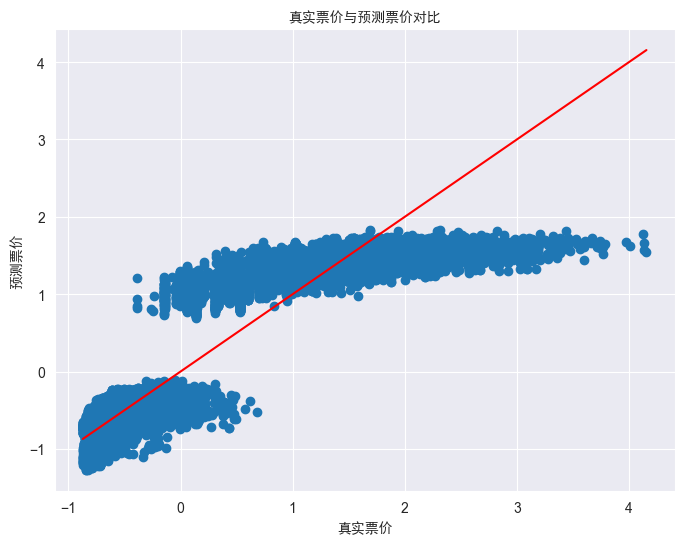

['../notebooks/preprocessor.pkl']

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Load data
df = pd.read_csv('../data/processed/clean_processed_data.csv')

# Print the columns to verify
print(df.columns)

# Prepare training data
X = df.drop(columns=['price'])  # Assuming 'price' is the target column
y = df['price']

# Define preprocessing for numeric features
numeric_features = ['duration', 'days_left']
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Define preprocessing for categorical features
categorical_features = [
    'airline_AirAsia', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo',
    'airline_SpiceJet', 'airline_Vistara', 'source_city_Bangalore', 'source_city_Chennai',
    'source_city_Delhi', 'source_city_Hyderabad', 'source_city_Kolkata', 'source_city_Mumbai',
    'departure_time_Afternoon', 'departure_time_Early_Morning', 'departure_time_Evening',
    'departure_time_Late_Night', 'departure_time_Morning', 'departure_time_Night',
    'stops_one', 'stops_two_or_more', 'stops_zero', 'arrival_time_Afternoon',
    'arrival_time_Early_Morning', 'arrival_time_Evening', 'arrival_time_Late_Night',
    'arrival_time_Morning', 'arrival_time_Night', 'destination_city_Bangalore',
    'destination_city_Chennai', 'destination_city_Delhi', 'destination_city_Hyderabad',
    'destination_city_Kolkata', 'destination_city_Mumbai', 'class_Business', 'class_Economy'
]
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a pipeline that includes preprocessing and model training
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a smaller parameter grid
param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0],
    'regressor__solver': ['auto', 'svd', 'cholesky']
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Output the best parameters
print("Best parameters:", grid_search.best_params_)

# Train the model with the best parameters
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# Predict prices
y_pred = best_model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R^2 Score: {r2}")

# Visualize the comparison between actual and predicted prices
font_path = 'C:/Windows/Fonts/simhei.ttf'  # You can choose another font path that supports Chinese
font_prop = fm.FontProperties(fname=font_path)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.title("真实票价与预测票价对比", fontproperties=font_prop)
plt.xlabel("真实票价", fontproperties=font_prop)
plt.ylabel("预测票价", fontproperties=font_prop)
# Save the plot as an image file in the figure directory
plt.savefig('../data/figure/comparison_plot.png')
plt.show()

# Fit the preprocessor
preprocessor.fit(X_train)

# Save the trained model and preprocessor
joblib.dump(best_model.named_steps['regressor'], '../notebooks/flight_price_model.pkl')
joblib.dump(preprocessor, '../notebooks/preprocessor.pkl')